# Introduction to MPI — Day 1: Concepts and Practice

**Teaching edition · NCI Training · Frederick Fung**

This notebook combines the core teaching material from *MPI-NCI-2026.tex* with the Day 1 exercises. Read each concept section, discuss its short check, then edit and run the linked C exercise. The explanations and diagrams needed for the lab are here; the original slides are optional further reading.

**By the end of Day 1 you should be able to:**

- Explain ranks, communicators, message matching, and ownership of a decomposed mesh.
- Recognise a blocking exchange that could deadlock.
- Overlap halo exchange with independent computation without using buffers too early.
- Create, restart, complete, and free persistent communication requests.

**Route through the notebook**

1. [Set up your session](#setup)
2. [MPI foundations and scaling](#foundations)
3. [First program: Monte Carlo pi](#monte-carlo)
4. [The Poisson model and domain decomposition](#model)
5. [Operations, messages, and buffer ownership](#semantics)
6. [Blocking communication and exercise](#blocking)
7. [Nonblocking communication and exercise](#nonblocking)
8. [Persistent communication and exercise](#persistent)
9. [Day 1 recap](#recap)

Continue afterwards with [Day 2: Concepts and Practice](../day2/mpi_lab2_teaching.ipynb).

<details>
<summary>Acknowledgement of Country</summary>

The National Computational Infrastructure acknowledges, celebrates and pays our respects to the Ngunnawal and Ngambri people of the Canberra region and to all First Nations Australians on whose traditional lands we meet and work, and whose cultures are among the oldest continuing cultures in human history.

</details>

*Adapted from the workshop slides and existing labs. Diagrams are embedded copies of the repository's teaching figures. C snippets in Markdown illustrate concepts; execute the notebook code cells and edit the linked `.c` files for the exercises. Keep this notebook in `day1/` so those links continue to work.*

## When to do the exercises

Follow the notebook from top to bottom. When you reach **STOP HERE — Exercise**, pause the concept reading, open the named file, complete the task, save it, and run the cell immediately below the exercise instructions. Use JupyterLab's file browser/text editor to edit C files; the code shown in Markdown explains the task. Replace each exercise's `#TODO` marker as you implement it. The shared `mesh.c` and `solver.c` are supplied for you.

| Stop point | File to open | Action |
|---|---|---|
| [Exercise 1.1 — first MPI program](#day1-exercise-1) | [day1/MC_pi.c](./MC_pi.c) | Read, identify the MPI stages, and run |
| [Exercise 1.2 — blocking exchange](#day1-exercise-2) | [day1/laplace_mpi_blocking.c](./laplace_mpi_blocking.c) | Edit the missing exchange, save, and run |
| [Exercise 1.3 — nonblocking exchange](#day1-exercise-3) | [day1/laplace_mpi_nonblocking.c](./laplace_mpi_nonblocking.c) | Combine the requests, save, and run |
| [Exercise 1.4 — persistent exchange](#day1-exercise-4) | [day1/laplace_mpi_persistent.c](./laplace_mpi_persistent.c) | Initialise, restart, and free requests; save and run |

The [deadlock demonstration](#day1-deadlock-demo) is an optional activity within the blocking section. The reference solutions are available in expandable panels at each coding exercise.

<a id="setup"></a>

## Setup

Open this notebook in a Jupyter session with a C compiler, `make`, `mpicc`, and `mpiexec` available to the kernel. On Gadi, use a compute allocation or an ARE JupyterLab session with enough CPUs for the chosen rank count. Load the compiler and MPI modules specified by the instructor before starting Jupyter; compile and run with the same MPI installation. See [setup instructions](../README.md).

Start Jupyter from the repository or set `MPI_TRAINING_ROOT` to its absolute path first. The next cell locates the repository without assuming a particular scratch project. `MPI_NPROCS` defaults to 4; set it before starting Jupyter to use another rank count within your allocation. These solvers require at least two interior rows per rank: `mesh_size >= 2 * nprocs + 2`.

Exercise files contain `#TODO` markers that intentionally prevent compilation. Replace each marker while completing its exercise. Completed examples are in `solution/`. A successful compile is followed by a numerical check; see the expected residual below.

In [ ]:
import os
from pathlib import Path

# Set MPI_TRAINING_ROOT before starting Jupyter if the kernel starts elsewhere.
root_hint = os.environ.get("MPI_TRAINING_ROOT")
candidates = [Path(root_hint).expanduser()] if root_hint else [Path.cwd(), *Path.cwd().parents]
repo_root = next((p for p in candidates if (p / "day1/mpi_lab1.ipynb").is_file()
                  and (p / "day2/mpi_lab2.ipynb").is_file()), None)
if repo_root is None:
    raise FileNotFoundError("Set MPI_TRAINING_ROOT to your clone's absolute path and restart Jupyter.")
os.chdir(repo_root / "day1")
nprocs = int(os.environ.get("MPI_NPROCS", "4"))
if nprocs < 1:
    raise ValueError("MPI_NPROCS must be positive")
print(f"Working directory: {Path.cwd()}; MPI ranks: {nprocs}")


<a id="foundations"></a>

## MPI foundations: who runs what?

**MPI (Message Passing Interface) is a standard**, with implementations such as MPICH, Open MPI, and Intel MPI. It defines communication operations; it does not divide a serial program's work for you. We use the C bindings in this workshop. The slides use MPI 4.0 as their reference level; most routines in these labs predate it.

With `mpiexec -np 4 ./program`, the launcher starts four processes. In the model used here, they execute the same program with different data: **single program, multiple data (SPMD)**. Each process has its own variables and address space. Writing `submesh[i][j]` on rank 0 does not update rank 1's copy. Processes may share a physical node or run on different nodes; explicit communication is still needed.

The programmer decides:

1. Which process owns each piece of work or data.
2. What another process needs and when it needs it.
3. Which MPI operations exchange that information safely.

### Rank and communicator

A **communicator** identifies a process group and a communication context. A **rank** is a process's integer position within that communicator, from 0 to `size - 1`; it is not a CPU number. `MPI_COMM_WORLD` contains the processes in this lab's MPI job. Rank 0 is an ordinary process we choose to use as a root.

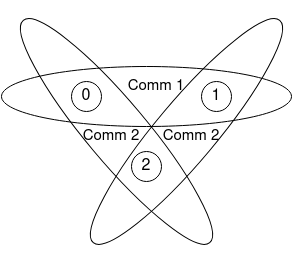

*Overlapping groups can exchange messages in separate communication contexts. A process may have a different rank in each communicator; messages on different communicators do not match.*

### Why parallelise? Strong and weak scaling

| Experiment | What stays fixed? | What grows? | Ideal outcome |
|---|---|---|---|
| Strong scaling | Total problem size | Number of ranks | Doubling ranks halves elapsed time |
| Weak scaling | Work per rank | Ranks and total work together | Elapsed time stays constant |

For fixed total work, speedup is $S_p=T_1/T_p$ and efficiency is $E_p=S_p/p$. Communication, serial work, and uneven workloads limit these ideals. For our square grid, keep `mesh_size` fixed for a strong-scaling experiment. For weak scaling, keeping the number of unknowns per rank roughly constant requires $N\propto\sqrt{p}$; the slab decomposition's communication cost can still change.

**Pause and predict:** if every rank runs the same executable, why do all ranks not calculate exactly the same part of the solution?

<details><summary>Check your reasoning</summary>

Each rank queries its rank and size, then uses them to select its data and neighbours. MPI supplies the communication machinery; the code supplies the decomposition.

</details>

### The lifecycle of the first MPI program

The six basic calls in the slides are `MPI_Init`, `MPI_Comm_rank`, `MPI_Comm_size`, `MPI_Send`, `MPI_Recv`, and `MPI_Finalize`. Our Monte Carlo example also uses a reduction and timing.

```c
#include <stdio.h>
#include <mpi.h>

int main(int argc, char **argv) {
    MPI_Init(&argc, &argv);
    int rank, size;
    MPI_Comm_rank(MPI_COMM_WORLD, &rank);
    MPI_Comm_size(MPI_COMM_WORLD, &size);

    printf("Hello from rank %d of %d\n", rank, size);

    MPI_Finalize();
    return 0;
}
```

`MPI_Init` initialises MPI in processes started by the launcher; it does not itself launch those processes. Its C declaration is `int MPI_Init(int *argc, char ***argv);`. Initialise MPI before the communication calls used here. Some query routines, such as `MPI_Initialized`, may be called earlier.

Complete outstanding communications before `MPI_Finalize`; finalisation is collective over the connected processes. For an unrecoverable error where ranks cannot continue together, `MPI_Abort` can terminate the MPI job. In our solvers, rank 0 broadcasts input validity so all ranks take the same exit path on invalid input.

`MPI_Wtime()` measures local wall-clock time. Subtract two readings on the same rank. A barrier ensures every rank has entered it before any returns; it does **not** order their subsequent `printf` output.

### From serial sampling to parallel Monte Carlo

Sample $(x,y)$ in $[0,1]^2$. A point is inside the quarter unit disk when $x^2+y^2\leq1$, so $\pi\approx4\times\text{hits}/N$.

Each rank handles the half-open interval

```c
int start = rank * N / size;
int end = (rank + 1) * N / size;
```

These intervals cover the sample indices without overlaps, including when `N` is not divisible by `size`. Initialise a rank-dependent random seed **once before the loop**; resetting the seed inside it repeats samples. Each rank accumulates its local hit count and contributes **once** to `MPI_Reduce`, after sampling. Only the root uses the reduced count.

**Read before running:** find these stages in [MC_pi.c](./MC_pi.c). Predict which output comes from every rank and which comes only from rank 0. A pi estimate will vary between runs; exact agreement with pi is not the correctness criterion for a random experiment.

<a id="monte-carlo"></a>

## 0. Preliminary Example
Our first example ([MC_pi.c](./MC_pi.c)) for you to get a hang of MPI code is slightly more than a hello-world program. Nevertheless, it is a simple snippet showcasing a basic MPI program template. 

The program approximates Pi by Monte-Carlo method. In essence, $N$ number of random numbers are distributed to multiple processes. Each process independently calculates the number of random numbers that are inside a unit circle and the results are collected and summed at a root process (rank 0). 

Look out for the following parts in the program.
```cpp
#include <mpi.h>

MPI_Init(&argc, &argv);

MPI_Comm_rank(MPI_COMM_WORLD, &rank);

MPI_Comm_size(MPI_COMM_WORLD, &size);

MPI_Wtime();

MPI_Reduce(&count, &count_tot, 1, MPI_INT, MPI_SUM, 0, MPI_COMM_WORLD);

MPI_Barrier(MPI_COMM_WORLD);

MPI_Finalize();
```

Run the next cell to execute the MC_pi program.

<a id="day1-exercise-1"></a>

---

##  Exercise 1.1: Read and run your first MPI program

> **Do this now before starting the Poisson model.**
>
> **OPEN AND READ:** [day1/MC_pi.c](./MC_pi.c) in the JupyterLab text editor. This is a reading exercise; no code changes are required.

**Your task**

1. Locate `MPI_Init`, the rank/size queries, and `MPI_Finalize`.
2. Explain how `start` and `end` split the samples and why the random seed is initialised before the loop.
3. Find the local hit count and the `MPI_Reduce` that combines it. Predict which prints come from every rank and which come only from rank 0.

**Run the next code cell.** It builds `day1/MC_pi.c` with `make MC`, then launches the resulting program with `nprocs` ranks.

**Check before continuing:** the job finishes, rank 0 prints an estimate near π, and every rank reports a runtime. The estimate varies between runs; the rank print order is not guaranteed.

In [ ]:
!make clean && make MC && echo "Compilation Successful!" && mpiexec -np {nprocs} ./MC_pi

**Exercise 1.1 checkpoint:** The program finished and you can explain its rank-local work and reduction.

Once this holds, **continue to [the Poisson model](#model)**. If the build or run failed, stay with this exercise and check its TODO markers, messages, and request completion.

<a id="model"></a>

## 1. Code Description

### 1.1 The model problem

We solve the two-dimensional Poisson equation on the unit square $\Omega=[0,1]^2$:

\begin{align*}
-\Delta u &= f &&\text{in }\Omega,\\
u &= g &&\text{on }\partial\Omega.
\end{align*}

For this workshop, $f(x,y)=2\pi^2\sin(\pi x)\sin(\pi y)$ and $g=0$. The exact continuous solution is $u(x,y)=\sin(\pi x)\sin(\pi y)$, which is useful for validation.

Let $N$ (`mesh_size`) be the number of grid points per dimension, including boundaries. Then $h=1/(N-1)$, $x_i=ih$, and $y_j=jh$ for $i,j=0,\ldots,N-1$. There are $(N-2)^2$ interior unknowns.

### 1.2 Discretisation

The second-order central finite difference formula is

$$(-\Delta u)_{i,j}\approx
\frac{4u_{i,j}-u_{i-1,j}-u_{i+1,j}-u_{i,j-1}-u_{i,j+1}}{h^2}=f(x_i,y_j).$$

The corresponding five-point stencil is

$$\frac{1}{h^2}\begin{pmatrix}&-1&\\-1&4&-1\\&-1&\end{pmatrix}.$$

Writing the interior unknowns row by row gives $Au=b$, where $b$ contains sampled values of $f$ and any contributions from prescribed boundary values. With $m=N-2$,

$$A=\frac{1}{h^2}\begin{pmatrix}
T&-I&&\\
-I&T&\ddots&\\
&\ddots&\ddots&-I\\
&&-I&T
\end{pmatrix},\qquad
T=\begin{pmatrix}
4&-1&&\\
-1&4&\ddots&\\
&\ddots&\ddots&-1\\
&&-1&4
\end{pmatrix}.$$

Here $T,I\in\mathbb{R}^{m\times m}$ and $A\in\mathbb{R}^{m^2\times m^2}$. For this problem's zero boundary values, $b$ is just the sampled interior right-hand side. The code applies the stencil directly without assembling $A$.

### 1.3 Numerical solver

For $A=D+L+U$, Jacobi iteration is

$$u^{(k+1)}=D^{-1}\bigl(b-(L+U)u^{(k)}\bigr).$$

In stencil form,

$$u^{(k+1)}_{i,j}=\frac{h^2 f_{i,j}+u^{(k)}_{i-1,j}+u^{(k)}_{i+1,j}+u^{(k)}_{i,j-1}+u^{(k)}_{i,j+1}}{4},
\qquad i,j=1,\ldots,N-2.$$

The implementation is in [solver.c](./solver.c). You do not need to change it for the communication exercises.


### 1.4 Convergence measurement

Let $u^\ast$ solve the discrete system $Au^\ast=b$, and define the algebraic error $e^{(k)}=u^{(k)}-u^\ast$. The residual is $r^{(k)}=b-Au^{(k)}$, so

$$Ae^{(k)}=-r^{(k)},\qquad
\|e^{(k)}\|\leq\|A^{-1}\|\,\|r^{(k)}\|.$$

For a fixed nonsingular system, a residual tending to zero implies the algebraic error tends to zero. The continuous solution also has a discretisation error, which is separate from this iteration error.

Small changes between iterates alone are not a general guarantee of accuracy. For this particular Jacobi method, however, the change is directly related to the residual:

$$u^{(k+1)}-u^{(k)}=D^{-1}r^{(k)}=\frac{h^2}{4}r^{(k)}.$$

**What the program reports:** [solver.c](./solver.c) returns each rank's sum of squares of $h^2(Au-b)$. After summing across ranks and taking a square root, the printed value is $h^2\|Au-b\|_2$, a scaled Euclidean residual. Compare variants at the same mesh size and iteration count; this scaled value is not directly comparable across mesh sizes.

The executable arguments are `mesh_size max_iter Jacobi`. The solver performs exactly `max_iter` iterations and then measures the residual; it does not stop at a tolerance.

**Expected result:** with an 18×18 grid and 10 iterations, each completed variant should print a residual of approximately **0.488953**, with 1, 2, or 4 ranks. With the notebook's 300×300 grid and 1000 iterations, expect approximately **0.031236**. Small floating-point differences between reductions are normal.

For this test problem, the exact residual in exact arithmetic is

$$R_k=\frac{\pi^2}{N-1}\cos\left(\frac{\pi}{N-1}\right)^k.$$

Jacobi converges slowly on fine grids: its iteration matrix has spectral radius $\rho=\cos(\pi h)=1-\mathcal{O}(h^2)$. We use it to make the communication patterns easy to study. Practical Poisson solvers often use preconditioned conjugate gradients or multigrid.


### 1.5 Parallelisation
As illustrated below, the unit square domain is decomposed into subdomains for parallelisation. Each MPI process hosts a subdomain. 
```cpp
double (*submesh)[mesh_size] = malloc(sizeof *submesh * *ptr_rows);
```
where mesh_size is the number of grid points per dimension. 


The decomposition is performed vertically, resulting two rows of ghost nodes on the top and the bottom for each subdomain.
```cpp
/* top row of ghost nodes */
submesh[*ptr_rows -1]

/*bottom row of ghost nodes */
submesh[0]
```
The mesh initialisation is written in [mesh.c](./mesh.c). Please do not edit.

Note that the value that the pointer ptr_rows pointing to is different for the top slab subdomain as it may host extra number of rows. The following example demonstrates the decomposition for a domain of 27x27 distributed to 4 MPI processes. 

```text
+-------------+  
|MPI Process 3| -> subdomain 27 x 9 (7 interior rows + 2 ghost rows) top ghost row is used as the boundary
+-------------+ 
|MPI Process 2| -> subdomain 27 x 8 (6 interior rows + 2 ghost rows)
+-------------+
|MPI Process 1| -> subdomain 27 x 8 (6 interior rows + 2 ghost rows)
+-------------+ 
|MPI Process 0| -> subdomain 27 x 8 (6 interior rows + 2 ghost rows) bottom ghost row is used as the boundary
+-------------+
```

### Why the mesh needs ghost rows

An **owned node** (called a *full node* in the slides) is updated by its owning rank. A **ghost node** is a local copy of a neighbour's owned value. Ghosts supply the five-point stencil near a partition boundary; they are not additional unknowns.

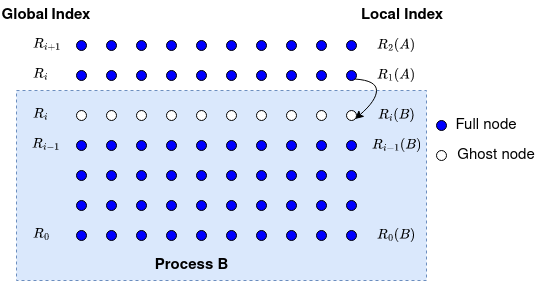

For a local allocation with `R = *ptr_rows` rows:

| Local row | Meaning | Action each iteration |
|---|---|---|
| `0` | Bottom ghost, or the physical bottom boundary | Receive from the lower rank if it exists |
| `1` | First owned row | Send to the lower rank |
| `2` through `R-3` | Owned rows independent of new halo data | Compute while transfers are pending |
| `R-2` | Last owned row | Send to the upper rank |
| `R-1` | Top ghost, or the physical top boundary | Receive from the upper rank if it exists |

All rows also contain fixed left and right boundary values. Only columns `1` through `mesh_size-2` are updated. The top rank receives the remainder when interior rows do not divide evenly.

At a physical edge, the code uses `MPI_PROC_NULL` for the missing neighbour. A point-to-point send or receive with this special rank completes without transferring data; a receive leaves the buffer unchanged. This preserves the boundary values.

**Check:** why must we exchange halos again after the final Jacobi update before measuring the residual?

<details><summary>Check your reasoning</summary>

The final update changes owned values, but the ghosts still contain values from the preceding iteration. The residual must use neighbours from the same final iterate, so it needs one final exchange.

</details>

<a id="semantics"></a>

## From an MPI operation to a C call

The slides distinguish an **operation** (the whole communication activity), a **procedure** (a language-independent action such as `MPI_SEND`), and a **C binding** (the callable spelling, such as `MPI_Send`). Think of the four operation stages as: bind arguments, start communication, complete communication, release its resources.

| Form | Bind/start | Complete | Release |
|---|---|---|---|
| Blocking | `MPI_Send` or `MPI_Recv` | Before that call returns | Handled by the call |
| Nonblocking | `MPI_Isend` or `MPI_Irecv` | `MPI_Wait` or successful `MPI_Test` | Ordinary request is released on completion |
| Persistent | Bind with `MPI_Send_init` / `MPI_Recv_init`; activate with `MPI_Start` | `MPI_Wait` or successful `MPI_Test`; request becomes inactive | Explicit `MPI_Request_free` after last use |

**Blocking** describes the calling process's completion semantics; it does not mean every process waits. **Local/nonlocal** describes whether completion depends on another process's participation. These are different questions. A standard blocking send may need its peer to post a receive.

The [MPI operation model](https://www.mpi-forum.org/docs/mpi-4.1/mpi41-report/node29.htm) explains these stages; the table shows the subset used by our labs.

### A message has data and an envelope

| Part | Fields | Meaning in the halo exchange |
|---|---|---|
| Data | Buffer address, count, datatype | A row starting at `submesh[1]`, containing `mesh_size` values of type `MPI_DOUBLE` |
| Envelope | Source, destination, tag, communicator | Which neighbour, which kind of message, and which communication context |

A receive matches the sender's communicator, destination, source, and tag. `MPI_ANY_SOURCE` and `MPI_ANY_TAG` are receive-side wildcards; sends specify a destination and non-negative tag. Our halo exchange uses explicit neighbours and two tags so the directions cannot be confused.

`count` is a number of datatype elements, **not bytes**. Match C `double` with `MPI_DOUBLE`, and C `int` with `MPI_INT`. Derived datatypes describe layouts such as noncontiguous columns or mixed records; a derived MPI datatype is a description of memory, not a new C type.

A receive buffer must have enough capacity for the incoming message and compatible element types. After a completed receive, `status.MPI_SOURCE` and `status.MPI_TAG` identify the message, and `MPI_Get_count` gives the received element count. `MPI_STATUS_IGNORE` is appropriate when those details are not needed.

**Check:** do matching tags allow a message sent on one communicator to satisfy a receive on another?

<details><summary>Answer</summary>

No. The communicator is part of message matching and isolates communication contexts.

</details>

<a id="blocking"></a>

## 2. Blocking Communication

### What “blocking” guarantees

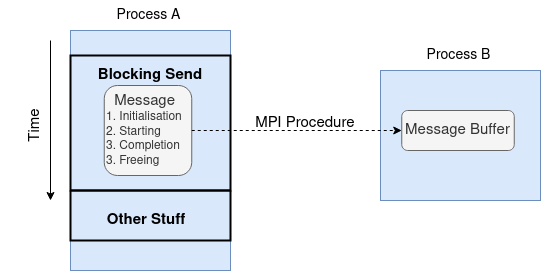

A completed **send** means the application may reuse its send buffer. The data may already be at the receiver or may have been copied into an MPI buffer. It does not generally mean the receiver has returned from its receive.

A completed **receive** means the received data are available in the receive buffer. The receive's element count is its capacity, rather than a requirement that the sender fill it completely.

### Four send modes, one blocking receive interface

| Mode | C call | What you must understand |
|---|---|---|
| Standard | `MPI_Send` | MPI may buffer the message or wait for a matching receive; do not depend on buffering |
| Buffered | `MPI_Bsend` | In this workshop's MPI 4.0 model, attach sufficient application buffer space with `MPI_Buffer_attach`; include MPI buffering overhead |
| Synchronous | `MPI_Ssend` | Completion requires that a matching receive has started receiving the message |
| Ready | `MPI_Rsend` | The matching receive must already be posted when the send starts; otherwise the program is erroneous |

All four modes can match `MPI_Recv`. Their nonblocking counterparts are `MPI_Isend`, `MPI_Ibsend`, `MPI_Issend`, and `MPI_Irsend`. The [communication-mode definitions](https://www.mpi-forum.org/docs/mpi-2.2/mpi22-report/node53.htm) distinguish buffer reuse from peer participation.

### A program that only works for small messages may be wrong

Suppose two ranks both execute a blocking send to each other, followed by a receive. Small messages might fit in internal buffers. Larger messages may require a handshake with the receiver; then neither rank reaches its receive but hangs on send.

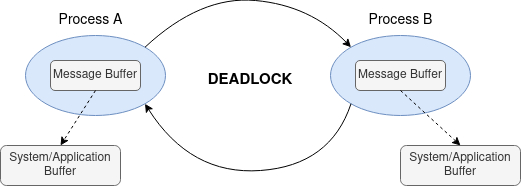

| Rank 0 | Rank 1 |
|---|---|
| `MPI_Send(..., 1, ...)` | `MPI_Send(..., 0, ...)` |
| `MPI_Recv(..., 1, ...)` | `MPI_Recv(..., 0, ...)` |

This ordering is unsafe. Common remedies are a coordinated send/receive order, `MPI_Sendrecv`, or posting nonblocking receives and sends before waiting. In this lab's chain of ranks, the physical edges and `MPI_PROC_NULL` allow the supplied blocking exchanges to progress. Trace the dependencies to check this; replacing the line of ranks with a ring changes the argument.

**Before editing:** identify the outgoing owned row, incoming ghost row, neighbour, and tag for the missing direction. Use the row table above. The exercise below deliberately asks for `MPI_Send` and `MPI_Recv` so you practise matching and ordering.

<a id="day1-deadlock-demo"></a>

## Observe a deadlock

> **FILE:** [day1/mpi_deadlock.c](./mpi_deadlock.c). Run the supplied program with the bounded terminal command below. Apply the suggested fix only for the optional follow-up.

### Try a deadlock with 16 MiB messages

[mpi_deadlock.c](./mpi_deadlock.c) sends a fixed 16 MiB message between two ranks. The complete program is:

```c
/* Intentional unsafe ordering with 16 MiB messages.
 * Compile: mpicc -Wall -Wextra -o mpi_deadlock mpi_deadlock.c
 * Run: timeout --kill-after=2s 5s mpiexec -np 2 ./mpi_deadlock
 */
#include <stdio.h>
#include <mpi.h>

#define MESSAGE_BYTES (16 * 1024 * 1024)

/* Static buffers are zero-initialised and do not use the stack. */
static char outgoing[MESSAGE_BYTES];
static char incoming[MESSAGE_BYTES];

int main(int argc, char **argv)
{
    MPI_Init(&argc, &argv);

    int rank, size;
    MPI_Comm_rank(MPI_COMM_WORLD, &rank);
    MPI_Comm_size(MPI_COMM_WORLD, &size);
    if (size != 2) {
        if (rank == 0) fprintf(stderr, "Run with exactly 2 ranks.\n");
        MPI_Finalize();
        return 1;
    }

    int peer = 1 - rank;
    printf("Rank %d: sending 16 MiB to rank %d\n", rank, peer);
    fflush(stdout);

    /* Both sends can wait for receives that neither rank has posted. */
    MPI_Send(outgoing, MESSAGE_BYTES, MPI_BYTE, peer, 0, MPI_COMM_WORLD);
    MPI_Recv(incoming, MESSAGE_BYTES, MPI_BYTE, peer, 0,
             MPI_COMM_WORLD, MPI_STATUS_IGNORE);

    printf("Rank %d: received the message\n", rank);
    MPI_Finalize();
    return 0;
}
```

Both ranks send before receiving. If the send requires a matching receive, rank 0 waits for rank 1, and rank 1 waits for rank 0. Neither reaches `MPI_Recv`.

Small messages may be buffered, allowing this unsafe ordering to finish. A 16 MiB message commonly requires a receive handshake and exposes the deadlock. The exact threshold depends on the active transport and configuration; MPI does not guarantee a particular cutoff. See the [MPI buffering discussion](https://www.mpi-forum.org/docs/mpi-4.1/mpi41-report/node68.htm).

Run in a terminal in `day1/`, with two CPUs available in your compute allocation:

```bash
mpicc -Wall -Wextra -o mpi_deadlock mpi_deadlock.c
timeout --kill-after=2s 5s mpiexec -np 2 ./mpi_deadlock
```

Expect two “sending” lines in either order. If the exchange deadlocks, no “received” lines appear and the timeout stops the job after five seconds. Its nonzero exit status is expected for the intentional hang.

**Optional follow-up — fix it:** replace the send and receive calls with the following, then rebuild and rerun:

```c
MPI_Sendrecv(outgoing, MESSAGE_BYTES, MPI_BYTE, peer, 0,
             incoming, MESSAGE_BYTES, MPI_BYTE, peer, 0,
             MPI_COMM_WORLD, MPI_STATUS_IGNORE);
```

Both ranks can now exchange their messages and finish. The buffers are separate, so receiving does not overwrite data being sent.

**After the demonstration:** continue to the halo-exchange explanation, then stop at [Exercise 1.2](#day1-exercise-2).


Each subdomain needs to update its ghost rows from neighbouring processes and send the top and bottom rows of full nodes to the neighbouring processes. 

For a MPI process $i$ to recv the update on the top row of ghost nodes with a standard blocking communication, we use
```cpp 
/* on MPI process i */
 MPI_Recv(submesh[*ptr_rows -1], mesh_size, MPI_DOUBLE, upper, highertag, MPI_COMM_WORLD, &status);
```

This requires the upper rank $i+1$ to coordinate with a send call
```cpp
/* on MPI process i+1 */
MPI_Send(submesh[1], mesh_size, MPI_DOUBLE, lower, highertag, MPI_COMM_WORLD);
```

Because every processes will execute those two calls, they can be put together without specifying the rank. See [laplace_mpi_blocking.c](./laplace_mpi_blocking.c).

<a id="day1-exercise-2"></a>

---

##  Exercise 1.2: Complete the blocking halo exchange

> **Do this exercise now, before moving to the next concept section.**
>
> **EDIT:** [day1/laplace_mpi_blocking.c](./laplace_mpi_blocking.c) in the JupyterLab text editor.
>
> **FIND:** `#TODO: complete the communication for the lowertag messages.` inside the iteration loop.

**Your task**

1. Add the missing exchange to update the bottom ghost row from the lower neighbour.
2. Send the top owned row to the upper neighbour with the matching tag. Check that the send/receive ordering can progress at both physical edges.
3. Replace the TODO marker with your implementation; keep the supplied Jacobi update.

**MPI calls:** `MPI_Send`, `MPI_Recv`

**Check before continuing:** The run finishes and reports a final residual near **0.031236** after 1000 iterations.

<details>
<summary>Reference solution — open after attempting the exercise</summary>

Compare with [day1/solution/laplace_mpi_blocking.c](./solution/laplace_mpi_blocking.c). Make your changes in the exercise file above.

</details>

**Save `day1/laplace_mpi_blocking.c`, then run the next code cell.** It compiles your saved file and runs it with `300 1000 Jacobi`.

In [ ]:
!make clean && make blocking && echo "Compilation Successful!" && mpiexec -np {nprocs} ./laplace_mpi_blocking 300 1000 Jacobi > convergence_blocking.txt && tail -20 convergence_blocking.txt 

**Exercise 1.2 checkpoint:** Your blocking exchange finishes and the residual is near 0.031236.

Once this holds, **continue to [nonblocking communication](#nonblocking)**. If the build or run failed, stay with this exercise and check its TODO markers, messages, and request completion.

<a id="nonblocking"></a>

## 3. Nonblocking Communication

### Separate initiation from completion

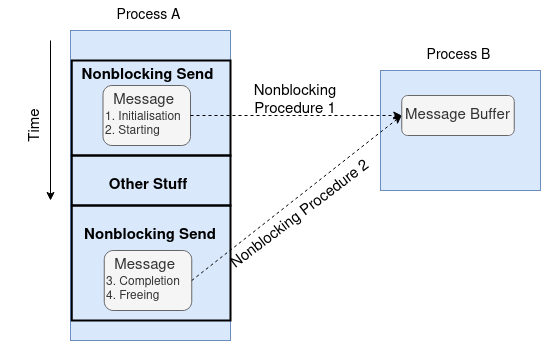

`MPI_Isend` and `MPI_Irecv` initiate communication and return request handles. Their return does **not** mean the transfer is complete.

- Do not modify a send buffer until its send request completes.
- Do not read or write a receive buffer until its receive request completes.
- Other buffers and computations that do not depend on incoming data can be used in the meantime.

| Completion call | Behaviour |
|---|---|
| `MPI_Wait(&request, &status)` | Wait until one operation completes |
| `MPI_Waitall(n, requests, statuses)` | Wait until all listed operations complete |
| `MPI_Test(&request, &flag, &status)` | Return immediately; `flag` tells whether the operation completed |
| `MPI_Testall(n, requests, &flag, statuses)` | Return immediately; `flag` is true when all listed operations completed |

The C declaration of `MPI_Test` includes the completion flag:

```c
int MPI_Test(MPI_Request *request, int *flag, MPI_Status *status);
```

A function's return code reports success or an error; it is **not** the completion flag. After successful completion, an ordinary nonpersistent request becomes `MPI_REQUEST_NULL`. The [initiation rules](https://www.mpi-forum.org/docs/mpi-4.1/mpi41-report/node73.htm) define when MPI may access the buffers.

### Where our Jacobi solver can overlap communication and work

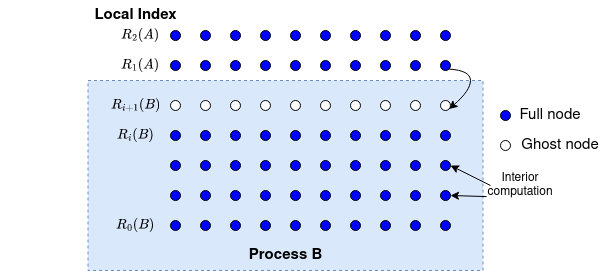

```text
Post receives and sends for the two edges
        |
        +-- Jacobi_int: compute rows that do not need new ghost values
        |
Complete the required requests
        |
        +-- Jacobi_top / Jacobi_bottom: compute the edge rows
        |
Copy the updated owned values into the original mesh
```

`Jacobi_int` writes into `submesh_new`, leaving the outgoing rows in `submesh` unchanged while sends may still be pending. The edge updates need the corresponding receives to be complete. Before copying all new values back, both outgoing sends must also be complete.

Nonblocking calls create an **opportunity** for overlap. Actual speedup depends on independent work, MPI progress, and the machine; it is not guaranteed merely by using an `I`-prefixed routine. See the [MPI progress discussion](https://www.mpi-forum.org/docs/mpi-4.1/mpi41-report/node48.htm).

**Check:** is waiting only for the two receives enough before overwriting the entire old mesh?

<details><summary>Answer</summary>

No. The two sends may still be reading their source rows. Wait for those sends too before reusing the old mesh. A four-request `MPI_Waitall` is the simple approach used by this exercise's solution.

</details>

During the communication between MPI processes, the iterative method can perform on interior grid nodes (except top and bottom full nodes) concurrently. To this end, a `Jacobi_int` routine is used and separated from `Jacobi_top` and `Jacobi_bottom` (see [solver.c](./solver.c)).

Hence, the communication starts from sending and receiving data for the top and bottom rows, and is followed by the `Jacobi_int` routine. Before applying `Jacobi_top` and `Jacobi_bottom` respectively, one needs to ensure the corresponding communication call is completed. The communications use `MPI_Request`
```cpp
 MPI_Request top_bnd_requests[2],  bottom_bnd_requests[2];
```
to identify the communications. 

The starter in [laplace_mpi_nonblocking.c](./laplace_mpi_nonblocking.c) tests the top and bottom request groups once, then computes each edge after its required communication completes, waiting as needed. 
```cpp
    /* Test on either the top or bottom layer */
    if ( (MPI_Testall(2, top_bnd_requests, &top_flag, top_bnd_status) > 0) || (MPI_Testall(2, bottom_bnd_requests, &bottom_flag, bottom_bnd_status) > 0))
    {
       MPI_Abort(MPI_COMM_WORLD, 1);
    }

    /* if the top layer is ready */
    if (top_flag){
        /* perform jacobi on the top bnd */
        Jacobi_top(ptr_rows, mesh_size, &submesh[0][0], &submesh_new[0][0], &subrhs[0][0], space);

    /* if the the bottom layer is ready */
    if (bottom_flag){
    /* perform jacobi on the bottom bnd */
    Jacobi_bottom(ptr_rows, mesh_size, &submesh[0][0], &submesh_new[0][0], &subrhs[0][0], space);
    }
    
    /* if the bottom layer is yet ready */
    else{
        /* wait on the bottom layer */
        MPI_Waitall(2, bottom_bnd_requests, bottom_bnd_status);
        Jacobi_bottom(ptr_rows, mesh_size, &submesh[0][0], &submesh_new[0][0], &subrhs[0][0], space);        
        }
    }
    /* if the top layer is yet ready but the bottom is */
    else if (bottom_flag){
        /* perform jacobi bottom ready */
        Jacobi_bottom(ptr_rows, mesh_size, &submesh[0][0], &submesh_new[0][0], &subrhs[0][0], space);
        /* wait on the top layer */
        MPI_Waitall(2, top_bnd_requests, top_bnd_status);
        Jacobi_top(ptr_rows, mesh_size, &submesh[0][0], &submesh_new[0][0], &subrhs[0][0], space);
        }
    /* if neither of the top and bottom is ready, then wait on both */
    else {
        MPI_Waitall(2, bottom_bnd_requests, bottom_bnd_status);
        Jacobi_bottom(ptr_rows, mesh_size, &submesh[0][0], &submesh_new[0][0], &subrhs[0][0], space);
        MPI_Waitall(2, top_bnd_requests, top_bnd_status);
        Jacobi_top(ptr_rows, mesh_size, &submesh[0][0], &submesh_new[0][0], &subrhs[0][0], space);
    }
```
However, this may overcomplicate the program.

<a id="day1-exercise-3"></a>

---

##  Exercise 1.3: Overlaping computation with the nonblocking communication

> **Do this exercise now, before moving to the next concept section.**
>
> **EDIT:** [day1/laplace_mpi_nonblocking.c](./laplace_mpi_nonblocking.c) in the JupyterLab text editor.
>
> **FIND:** the two `#TODO` markers: the request declarations and the completion logic inside the loop.

**Your task**

1. Replace the separate top/bottom request groups with one array of four requests, and update all four nonblocking calls to use it.
2. Keep `Jacobi_int` between communication initiation and completion. Replace the split test/wait branches with one wait for all four requests, followed by the two edge updates.
3. Remove both TODO markers and declarations made redundant by your refactor. Keep the final copy into the original mesh.

**MPI calls:** `MPI_Irecv`, `MPI_Isend`, `MPI_Waitall`

**Check before continuing:** The run finishes with a residual near **0.031236**, matching Exercise 1.2. Explain why outgoing buffers are safe to overwrite only after their sends complete.

<details>
<summary>Reference solution — open after attempting the exercise</summary>

Compare with [day1/solution/laplace_mpi_nonblocking.c](./solution/laplace_mpi_nonblocking.c). Make your changes in the exercise file above.

</details>

**Save `day1/laplace_mpi_nonblocking.c`, then run the next code cell.** It compiles your saved file and runs it with `300 1000 Jacobi`.

In [ ]:
!make clean && make nonblocking && echo "Compilation Successful!" && mpiexec -np {nprocs} ./laplace_mpi_nonblocking 300 1000 Jacobi > convergence_nonblocking.txt && tail -20 convergence_nonblocking.txt 

**Exercise 1.3 checkpoint:** Your four-request version matches the blocking residual.

Once this holds, **continue to [persistent communication](#persistent)**. If the build or run failed, stay with this exercise and check its TODO markers, messages, and request completion.

<a id="persistent"></a>

## 4. Persistent Communication

### Reuse a communication description

The halo exchange repeats the same buffer addresses, neighbours, tags, datatypes, and counts on every iteration. Persistent communication binds those arguments once, then activates the requests repeatedly with new buffer contents. This can reduce setup overhead; it does not reduce the number of values that must cross the network.

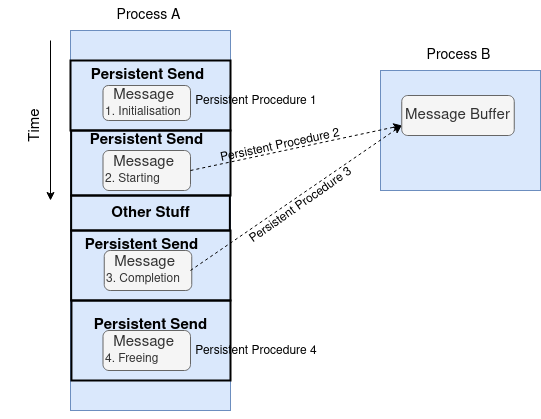

```text
MPI_Send_init / MPI_Recv_init  -> inactive request
                                     |
                               MPI_Start / MPI_Startall
                                     |
                                  active
                                     |
                               MPI_Wait / successful MPI_Test
                                     |
                                  inactive ---- restart on the next iteration
                                     |
                               MPI_Request_free after final use
```

Both sends **and receives** can be persistent. Complete an active request before starting it again. Unlike an ordinary nonblocking request, a persistent request survives completion and becomes inactive. Never treat a false `MPI_Testall` flag as permission to consume newly received values.

The buffer **address** is fixed by initialisation; its contents can change while the request is inactive. Our solver copies the new iterate back into the original mesh, preserving those addresses. A solver that swaps mesh pointers would need requests bound to both buffer arrangements or another suitable design.

`MPI_Request_free` frees one handle, not an entire array. If you create four requests, free all four after their final completion. A persistent send can match a nonpersistent receive and vice versa. See [persistent communication requests](https://www.mpi-forum.org/docs/mpi-4.1/mpi41-report/node83.htm).

**Before editing:** mark which statements belong outside the iteration loop and which belong inside. Keep the existing computation and completion dependencies intact.

You should now be quite familiar with our code, and may notice that the same communication is executed over and over again with updated data in the same buffers within the iteration loops. Recall the four stages of `MPI Operation` explained above. The `initialisation stage` hands over the argument list, which stays unchanged in our program. The persistent communication binds the argument list to the communication request once and repeatedly uses it in the subsequent communication calls.

<a id="day1-exercise-4"></a>

---

##  Exercise 1.4: Reuse persistent requests

> **Do this exercise now, before moving to the next concept section.**
>
> **EDIT:** [day1/laplace_mpi_persistent.c](./laplace_mpi_persistent.c) in the JupyterLab text editor.
>
> **FIND:** the three `#TODO` markers for initialisation, starting communication, and freeing requests.

**Your task**

1. Create all send and receive requests once, before the iteration loop.
2. Start the requests on every iteration. Keep the existing completion checks and waits before using received data or reusing outgoing buffers.
3. Free every request handle after its final completion, outside the loop, and replace all three TODO markers.

**MPI calls:** `MPI_Send_init`, `MPI_Recv_init`, `MPI_Startall`, `MPI_Testall`, `MPI_Waitall`, `MPI_Request_free`

**Check before continuing:** The final residual is near **0.031236**. Identify which calls run once and which run on every iteration.

<details>
<summary>Reference solution — open after attempting the exercise</summary>

Compare with [day1/solution/laplace_mpi_persistent.c](./solution/laplace_mpi_persistent.c). Make your changes in the exercise file above.

</details>

**Save `day1/laplace_mpi_persistent.c`, then run the next code cell.** It compiles your saved file and runs it with `300 1000 Jacobi`.

In [ ]:
!make clean && make persistent && echo "Compilation Successful!" && mpiexec -np {nprocs} ./laplace_mpi_persistent 300 1000 Jacobi > convergence_persistent.txt && tail -20 convergence_persistent.txt

**Exercise 1.4 checkpoint:** Your persistent version matches the earlier residuals and frees all requests.

Once this holds, **continue to [the Day 1 recap](#recap)**. If the build or run failed, stay with this exercise and check its TODO markers, messages, and request completion.

<a id="recap"></a>

## Day 1 recap and troubleshooting

| Symptom | First things to check |
|---|---|
| The job hangs | Matching communicator, ranks, tags, call order, and whether every request can complete |
| It works only for small messages | Accidental dependence on standard-send buffering |
| Residual differs between completed variants | Wrong ghost row, missing exchange, early buffer reuse, or different iteration counts |
| Nonblocking is not faster | Amount of independent work, time spent waiting, and actual MPI progress |
| Persistent version fails after a refactor | Buffer addresses changed or a request was restarted while active |

**Before continuing:** explain to a partner why `MPI_Send` completion and `MPI_Recv` completion are different guarantees, why `Jacobi_int` can run before waiting, and why a persistent request remains valid after completion.

For a small numerical comparison, build each completed solution in `solution/` and use the same arguments: `18 10 Jacobi`, with 1, 2, or 4 ranks. Expect a scaled residual near **0.488953**. The main exercise cells use `300 1000 Jacobi`, with a residual near **0.031236**. Compare correctness before interpreting performance.

**Next:** [Day 2 — collectives, RMA, MPI-IO, and profiling](../day2/mpi_lab2_teaching.ipynb).

Source: [NCI workshop slides](../docs/slides/MPI-NCI-2026.tex). This edition keeps the concepts needed for the exercises and corrects incomplete slide snippets. The slide history, survey statistics, and unstructured-grid showcase are optional background rather than required lab material.